In [38]:
#!pip install gensim pandas numpy matplotlib seaborn scikit-learn nltk tqdm

In [39]:
import sys
print(sys.version)


3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]


In [40]:
import re
import time
import logging
from pathlib import Path


In [41]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [42]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [43]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [45]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [46]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [47]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [49]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [50]:
# logging helps us to check how much work is done

In [51]:
logging.basicConfig(format='%(asctime)s:%(levelname)s:%(message)s',level=logging.INFO)

In [52]:
path = "Reviews.csv"

In [53]:
# throws error if file not in folder

In [54]:
if not Path(path).exists():
    raise FileNotFoundError(
        f"no file check folder again"
    )
df= pd.read_csv(path)

In [55]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [56]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [57]:
# drop rows with no entry

In [58]:
df = df.dropna(subset=['Text','Summary'])

In [59]:
df.head() # Never call whole df , it becames messy

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [60]:
df['full_text'] = df['Summary'].astype(str)+ " "+ df['Text'].astype(str)

In [61]:
df['full_text'][0] # this thing will be used to vectorize the matrix

'Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [62]:
raw_texts = df['full_text'].tolist()

In [63]:
stop_words = set(stopwords.words('english'))

In [64]:
lm = WordNetLemmatizer()

In [76]:
def cleantxt(text:str)->list[str]:
    text = re.sub(r'<[^>]+>',' ',text)
    text = re.sub(r'[^a-zA-Z]',' ',text)
    text = text.lower()
    tokens = word_tokenize(text)
    cleantok = [
        lm.lemmatize(word)
        for word in tokens
        if word not in stop_words
        and len(word)>= 2
        ]
    return cleantok


In [77]:
start = time.time()


In [78]:
sentences = [cleantxt(text)
             for text in tqdm(raw_texts,desc="Preprocessing")
             ]

Preprocessing: 100%|██████████| 568427/568427 [04:21<00:00, 2177.25it/s]


In [79]:
sentences = [s for s in sentences if len(s)>0]

In [80]:
elapsed  = time.time() - start

In [91]:
W2V_CONFIG = dict(
    vector_size = 300,window = 5,sg = 1,hs = 0,negative = 10,min_count = 5,sample = 1e-4,
    epochs = 10, workers = 4, alpha = 0.025,min_alpha = 0.0001,seed = 42,compute_loss= True
)

In [92]:
for k,v in W2V_CONFIG.items():
    print(f"{k:<15} = {v}")

vector_size     = 300
window          = 5
sg              = 1
hs              = 0
negative        = 10
min_count       = 5
sample          = 0.0001
epochs          = 10
workers         = 4
alpha           = 0.025
min_alpha       = 0.0001
seed            = 42
compute_loss    = True


In [93]:
class LossLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.losses = []
        self.prev_loss = 0 
    def on_epoch_end(self, model):
        cumulative_loss = model.get_latest_training_loss()
        epoch_loss = cumulative_loss -self.prev_loss
        self.prev_loss = cumulative_loss
        self.losses.append(epoch_loss)
        self.epoch += 1
loss_logger  = LossLogger()


In [94]:
start = time.time()

In [ ]:
model = Word2Vec(
    sentences= sentences,
    callbacks=[loss_logger],
    **W2V_CONFIG
)
elapsed = time.time() - start

2026-07-21 21:20:40,645:INFO:collecting all words and their counts
2026-07-21 21:20:40,647:INFO:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


2026-07-21 21:20:40,735:INFO:PROGRESS: at sentence #10000, processed 402851 words, keeping 16425 word types
2026-07-21 21:20:40,817:INFO:PROGRESS: at sentence #20000, processed 830871 words, keeping 23231 word types
2026-07-21 21:20:40,921:INFO:PROGRESS: at sentence #30000, processed 1257988 words, keeping 27957 word types
2026-07-21 21:20:41,004:INFO:PROGRESS: at sentence #40000, processed 1661774 words, keeping 31721 word types
2026-07-21 21:20:41,090:INFO:PROGRESS: at sentence #50000, processed 2087502 words, keeping 34982 word types
2026-07-21 21:20:41,171:INFO:PROGRESS: at sentence #60000, processed 2504928 words, keeping 38273 word types
2026-07-21 21:20:41,279:INFO:PROGRESS: at sentence #70000, processed 2949730 words, keeping 41194 word types
2026-07-21 21:20:41,379:INFO:PROGRESS: at sentence #80000, processed 3395987 words, keeping 43818 word types
2026-07-21 21:20:41,478:INFO:PROGRESS: at sentence #90000, processed 3834543 words, keeping 46432 word types
2026-07-21 21:20:41,5

In [96]:
model_path = "word2vec_amazon_reviews.model"
model.save(model_path)
print(f"model saved at {model_path}")

2026-07-21 22:38:31,379:INFO:Word2Vec lifecycle event {'fname_or_handle': 'word2vec_amazon_reviews.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-07-21T22:38:31.379210', 'gensim': '4.4.0', 'python': '3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'saving'}
2026-07-21 22:38:31,389:INFO:storing np array 'vectors' to word2vec_amazon_reviews.model.wv.vectors.npy
2026-07-21 22:38:31,478:INFO:storing np array 'syn1neg' to word2vec_amazon_reviews.model.syn1neg.npy
2026-07-21 22:38:31,565:INFO:not storing attribute cum_table
2026-07-21 22:38:32,073:INFO:saved word2vec_amazon_reviews.model


model saved at word2vec_amazon_reviews.model


Text(0, 0.5, 'loss')

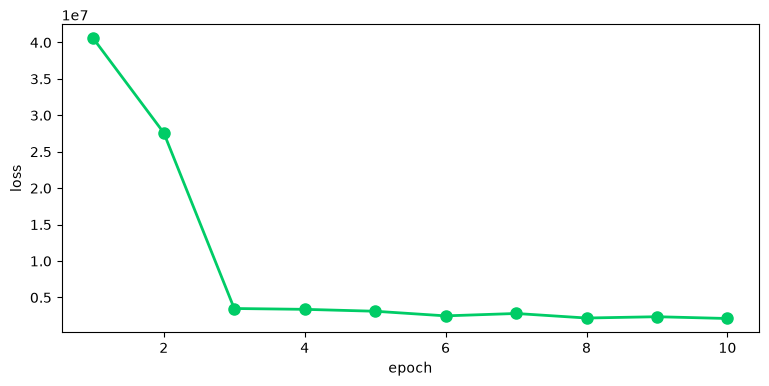

In [101]:
plt.figure(figsize=(9,4))
plt.plot(range(1,len(loss_logger.losses)+1),loss_logger.losses,marker ='o',
         color ='#00cc66',linewidth = 2,markersize = 8
         )
plt.xlabel("epoch")
plt.ylabel("loss")


In [113]:
word = 'good'
# word = 'delicious'
if word in model.wv:
    vec = model.wv[word]
    print(f"Vector for word '{word}': shape ={vec.shape}")
    print(f":10 values {vec[:10].round(4)}")
else:
    print(f"'{word}' not in data - try another word")

Vector for word 'good': shape =(300,)
:10 values [-0.0911 -0.007  -0.1393 -0.0602 -0.0471 -0.0841 -0.0147 -0.1566  0.0488
  0.106 ]


In [117]:
def similarwords(word,topn = 10):
    """Print Top-N similar words to the searched word"""
    if word not in model.wv:
        print(f"'{word}' not in vocab")
        return
    similar = model.wv.most_similar(word,topn = topn )
    print(f"most similar words to '{word}':")
    print(f" {'Word':<20}{'similar words ':>10}")
    print(" "+"-"*32)
    for w,score in similar:
        print(f"   {w:<20}{score:>10.4f}")


In [118]:
similarwords('delicious')
similarwords('terrible')
similarwords('good')

most similar words to 'delicious':
 Word                similar words 
 --------------------------------
   tasty                   0.7991
   yummy                   0.7589
   wonderful               0.6797
   flavorful               0.6743
   dellicious              0.6719
   flavorfully             0.6565
   yummilicious            0.6352
   fantastic               0.6328
   good                    0.6306
   breakast                0.6249
most similar words to 'terrible':
 Word                similar words 
 --------------------------------
   awful                   0.6002
   horrible                0.5904
   bad                     0.5574
   disgusting              0.5267
   worst                   0.5266
   yuck                    0.5190
   disguisting             0.5057
   poor                    0.5043
   ewwwwwwwwww             0.4963
   nasty                   0.4826
most similar words to 'good':
 Word                similar words 
 --------------------------------
   great   

In [119]:
# check the list that "good" and "delicious" are near to each other as they should be

In [121]:
def analogy (positive,negative,topn = 5):
    """SOvle : positive[0] is to positive[1] as negative[0] is to ?
    """

    try:
        results = model.wv.most_similar(
            positive=positive,
            negative = negative,
            topn = topn
        )
        q = "+".join(positive)+"-"+"-".join(negative)
        print(f"\n{q}")
        for w,score in results:
            print(f"{w:<20} (similarity:{score:.4f})")
    except KeyError as e:
        print(f"word not in vocab{e}")

In [123]:
analogy(['sweet','coffee'],negative=['bitter'])
analogy(['cheap','excellent'],negative=['bad'])
analogy(['buy','hated'],negative=['loved'])



sweet+coffee-bitter
satisfys             (similarity:0.4999)
memento              (similarity:0.4708)
yacky                (similarity:0.4688)
addidcted            (similarity:0.4652)
foryou               (similarity:0.4625)

cheap+excellent-bad
great                (similarity:0.4200)
quality              (similarity:0.4102)
exellent             (similarity:0.3994)
wonderful            (similarity:0.3978)
fantastic            (similarity:0.3942)

buy+hated-loved
purchase             (similarity:0.4832)
buying               (similarity:0.4801)
untried              (similarity:0.4297)
willbe               (similarity:0.4188)
jarrows              (similarity:0.4157)
